# N-gram Language Models

Unigram, bigram, and trigram language models from scratch on the 1 Billion Word Benchmark. Perplexity evaluation with and without Laplace smoothing, and text generation with greedy, random, and nucleus sampling.

### Importing libraries

In [338]:
import math
from collections import defaultdict, Counter
from nltk import FreqDist, ConditionalFreqDist, ngrams
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

### Reading train and test files

In [341]:
def read_sentences(filename): # reading all sentences from file and splitting each line into list of tokens
    with open(filename, 'r') as f:
        return [line.strip().split() for line in f.readlines()]

## PART-1:

## Building vocabulary

In [345]:
def build_vocab(sentences, min_count=3): # building vocabulary with tokens 
    flat_tokens = [token for sentence in train_sentences for token in sentence] # flattening training data to get frequency of each token
    token_freq = Counter(flat_tokens) # counting  of each token
    vocab = {token for token, count in token_freq.items() if count >= min_count} # creating vocabulary with tokens that occur 3 or more times
    vocab.update({"<unk>", "<STOP>"})
    return vocab 

## preprocessing sentences

In [348]:
def preprocess(sentences, vocab): # preprocessing sentences by replacing rare tokens and adding <STOP>
    processed_sentences = []
    for sentence in sentences:
        processed = [token if token in vocab else "<unk>" for token in sentence] # replacing tokens not in vocab with <unk>
        processed.append("<STOP>") # adding <STOP> token at end of each sentence
        processed_sentences.append(processed)
    return processed_sentences

## Building N-gram models

In [351]:
def unigram(sentences): # building unigram model using FreqDist
    all_tokens = [token for sentence in sentences for token in sentence]
    return FreqDist(all_tokens)

def bigram(sentences): # building bigram model using ConditionalFreqDist
    bigrams = []
    for sentence in sentences:
        tokens = ["<START>"] + sentence
        bigrams.extend(ngrams(tokens, 2)) # generating n-grams from tokens
    return ConditionalFreqDist(((w1,), w2) for (w1, w2) in bigrams)

def trigram(sentences): # building trigram model using ConditionalFreqDist
    trigrams = []
    for sentence in sentences:
        tokens = ["<START>", "<START>"] + sentence
        trigrams.extend(ngrams(tokens, 3)) # generating n-grams from tokens
    return ConditionalFreqDist(((w1, w2), w3) for (w1, w2, w3) in trigrams)

## Perplexity - no smoothing

In [356]:
def perplexity(model, test_sentences, n): # function to compute perplexity without smoothing
    total_log_prob = 0 
    total_tokens = 0
    for sentence in test_sentences: # adding <START> tokens to match n-gram context
        starts = ["<START>"] * (n - 1)
        tokens = starts + sentence
        for ngram in ngrams(tokens, n): # calculating probability of each n-gram
            context = ngram[:-1]
            word = ngram[-1] 
            if n == 1: # for unigram model is FreqDist and for higher it's ConditionalFreqDist
               prob = model.freq(word)
            else:
                context_freq = model[context] if context in model else None
                prob = context_freq.freq(word) if context_freq and context_freq.N() > 0 else 0
            if prob == 0:
                return float('inf') # if probability is 0 log becomes inf 
            total_log_prob += math.log(prob)
            total_tokens += 1
    return math.exp(-total_log_prob / total_tokens)

## Perplexity - Laplace smoothing

In [359]:
def perplexity_laplace(model, test_sentences, n, vocab_size): # function to compute perplexity with Laplace (add-one) smoothing
    total_log_prob = 0
    total_tokens = 0
    for sentence in test_sentences: # adding <START> tokens
        starts = ["<START>"] * (n - 1)
        tokens = starts + sentence
        for ngram in ngrams(tokens, n): 
            context = ngram[:-1]
            word = ngram[-1]
            if n == 1: # handling unknown contexts
                count = model[word] + 1
                total = model.N() + vocab_size
            else:
                context_freq = model[context] if context in model else FreqDist()
                count = context_freq[word] + 1
                total = context_freq.N() + vocab_size
            prob = count / total
            total_log_prob += math.log(prob)
            total_tokens += 1
    return math.exp(-total_log_prob / total_tokens)

## Running perplexity evaluation

In [362]:
train_sentences = read_sentences("1b_benchmark.train.tokens.txt") # reading training and test data
test_sentences = read_sentences("1b_benchmark.test.tokens.txt")

vocab = build_vocab(train_sentences, min_count=3)
print(f"Vocabulary size: {len(vocab)}") # printing vocab size

train_sentences = preprocess(train_sentences, vocab) # applying preprocessing to both training and test data
test_sentences = preprocess(test_sentences, vocab)

unigram_model = unigram(train_sentences) # training models
bigram_model = bigram(train_sentences)
trigram_model = trigram(train_sentences)

print("\n------ Perplexity (no smoothing)---------")
print("Unigram train:", perplexity(unigram_model, train_sentences, 1)) # printing perplexities for all model variants
print("Unigram test:", perplexity(unigram_model, test_sentences, 1))
print("Bigram train:", perplexity(bigram_model, train_sentences, 2))
print("Bigram test:", perplexity(bigram_model, test_sentences, 2))
print("Trigram train:", perplexity(trigram_model, train_sentences, 3))
print("Trigram test:", perplexity(trigram_model, test_sentences, 3))

vocab_size = len(vocab) # calculating vocabulary size for Laplace smoothing

print("\n------ Perplexity (Laplace smoothing)---------")
print("Unigram train:", perplexity_laplace(unigram_model, train_sentences, 1, vocab_size)) # printing Laplace smoothed perplexities
print("Unigram test:", perplexity_laplace(unigram_model, test_sentences, 1, vocab_size))
print("Bigram train:", perplexity_laplace(bigram_model, train_sentences, 2, vocab_size))
print("Bigram test:", perplexity_laplace(bigram_model, test_sentences, 2, vocab_size))
print("Trigram train:", perplexity_laplace(trigram_model, train_sentences, 3, vocab_size))
print("Trigram test:", perplexity_laplace(trigram_model, test_sentences, 3, vocab_size))

Vocabulary size: 26602

------ Perplexity (no smoothing)---------
Unigram train: 976.5437421980536
Unigram test: 896.4994914384728
Bigram train: 77.07346595679371
Bigram test: inf
Trigram train: 7.872967947055635
Trigram test: inf

------ Perplexity (Laplace smoothing)---------
Unigram train: 977.507936467968
Unigram test: 898.5561973416407
Bigram train: 1442.3086832710517
Bigram test: 1665.3873258510287
Trigram train: 6244.424900211697
Trigram test: 9649.607347810084


## Comparison table and bar chart

Perplexity Comparison Table:


,Model,Train - No Smoothing,Test - No Smoothing,Train - Laplace,Test - Laplace
0,Unigram,976.5437,896.4995,977.5079,898.5562
1,Bigram,77.0735,inf,1442.3087,1665.3873
2,Trigram,7.8730,inf,6244.4249,9649.6073


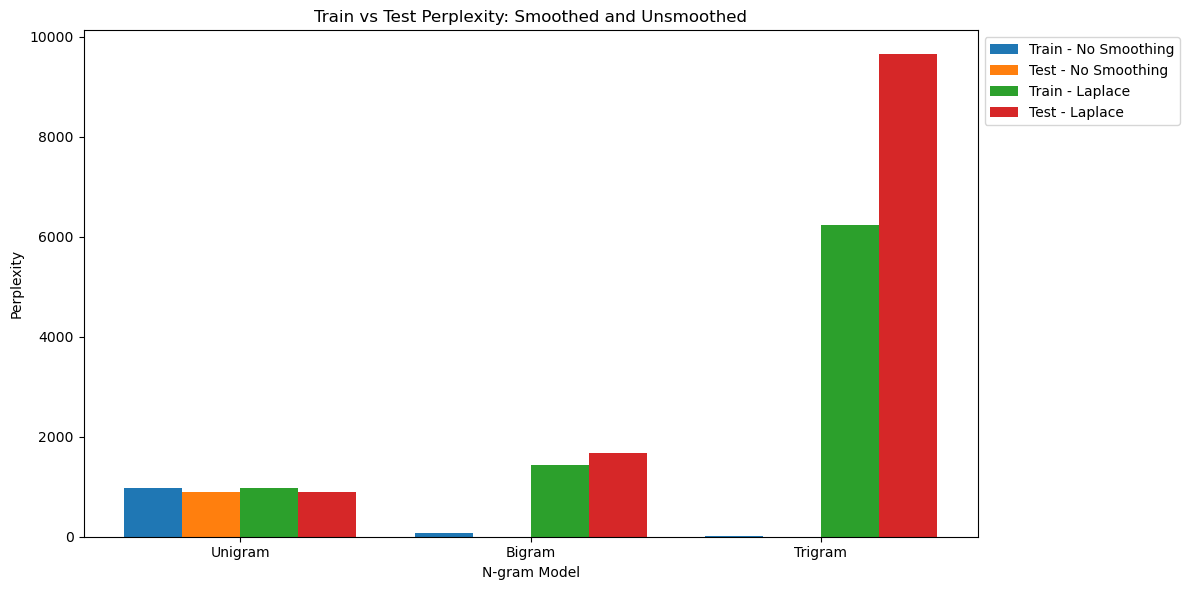

In [364]:
perplexities = { # storing perplexities from earlier computations
    "Model": ["Unigram", "Bigram", "Trigram"],
    "Train - No Smoothing": [
        perplexity(unigram_model, train_sentences, 1),
        perplexity(bigram_model, train_sentences, 2),
        perplexity(trigram_model, train_sentences, 3)],
    "Test - No Smoothing": [
        perplexity(unigram_model, test_sentences, 1),
        perplexity(bigram_model, test_sentences, 2),
        perplexity(trigram_model, test_sentences, 3)],
    "Train - Laplace": [
        perplexity_laplace(unigram_model, train_sentences, 1, vocab_size),
        perplexity_laplace(bigram_model, train_sentences, 2, vocab_size),
        perplexity_laplace(trigram_model, train_sentences, 3, vocab_size)],
    "Test - Laplace": [
        perplexity_laplace(unigram_model, test_sentences, 1, vocab_size),
        perplexity_laplace(bigram_model, test_sentences, 2, vocab_size),
        perplexity_laplace(trigram_model, test_sentences, 3, vocab_size)]}

df = pd.DataFrame(perplexities) # converting to dataFrame
print("Perplexity Comparison Table:") # printing table
display(df.round(4))
df_clean = df.replace([np.inf, -np.inf], np.nan) # replacing 'inf' with np.nan for plotting

fig, ax = plt.subplots(figsize=(12, 6)) # creating grouped bar chart Train vs Test for both smoothing types
bar_width = 0.2
index = np.arange(len(df_clean["Model"]))
ax.bar(index - 1.5*bar_width, df_clean["Train - No Smoothing"], bar_width, label='Train - No Smoothing') # plotting each bar group
ax.bar(index - 0.5*bar_width, df_clean["Test - No Smoothing"], bar_width, label='Test - No Smoothing')
ax.bar(index + 0.5*bar_width, df_clean["Train - Laplace"], bar_width, label='Train - Laplace')
ax.bar(index + 1.5*bar_width, df_clean["Test - Laplace"], bar_width, label='Test - Laplace')
ax.set_xlabel('N-gram Model') # labels
ax.set_ylabel('Perplexity')
ax.set_title('Train vs Test Perplexity: Smoothed and Unsmoothed')
ax.set_xticks(index)
ax.set_xticklabels(df_clean["Model"])
ax.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

## PART-2:

## Reading and combining training and test datasets

In [425]:
def read_sentences(filename):
    with open(filename, 'r') as f:
        return [line.strip().split() for line in f.readlines()]
train_sentences = read_sentences("1b_benchmark.train.tokens.txt")
test_sentences = read_sentences("1b_benchmark.test.tokens.txt")
merged_sentences = train_sentences + test_sentences

##  Building vocabulary

In [436]:
def build_vocab(sentences, min_count=3): # vocabulary from merged data
    flat_tokens = [token for sentence in all_sentences for token in sentence]
    token_freq = Counter(flat_tokens)
    vocab = {token for token, count in token_freq.items() if count >= min_count} # building vocab tokens that appear>= 3 times
    vocab.update(["<unk>", "<STOP>"]) # ensuring required tokens are included
    return vocab
vocab_merged = build_vocab(merged_sentences)
def preprocess(sentences, vocab): # preprocess merged data
    processed = []
    for sentence in sentences:
        tokens = [t if t in vocab else "<unk>" for t in sentence]
        tokens.append("<STOP>")
        processed.append(tokens)
    return processed
merged = preprocess(merged_sentences, vocab_merged)

## Building N-gram models

In [439]:
def unigram(sentences):
    tokens = [t for s in sentences for t in s]
    return FreqDist(tokens)

def bigram(sentences):
    model = ConditionalFreqDist()
    for s in sentences:
        tokens = ['<START>'] + s
        for w1, w2 in ngrams(tokens, 2):
            model[w1][w2] += 1
    return model

def trigram(sentences):
    model = ConditionalFreqDist()
    for s in sentences:
        tokens = ['<START>', '<START>'] + s
        for w1, w2, w3 in ngrams(tokens, 3):
            model[(w1, w2)][w3] += 1
    return model

# Build models
uni = unigram(merged)
bi = bigram(merged)
tri = trigram(merged)

## Sentence generation (Greedy, Random, Top-p sampling)

In [441]:
def generate_sentence(model, n=2, strategy="greedy", p=0.9, max_len=100):
    context = ['<START>'] * (n - 1)
    sentence = []

    for _ in range(max_len):
        if n == 1:
            dist = model
        else:
            key = tuple(context) if n == 3 else context[-1]
            dist = model.get(key, None)
        if not dist or len(dist) == 0:
            next_word = "<unk>"
        else:
            items = dist.items() if n > 1 else model.items()
            sorted_items = sorted(items, key=lambda x: x[1], reverse=True)

            if strategy == "greedy":
                next_word = sorted_items[0][0]
            elif strategy == "random":
                words, weights = zip(*sorted_items)
                next_word = random.choices(words, weights=weights)[0]
            elif strategy == "top-p":
                total = sum(c for _, c in sorted_items)
                cumulative = 0
                top_p = []
                for w, c in sorted_items:
                    cumulative += c
                    top_p.append((w, c))
                    if cumulative / total >= p:
                        break
                words, weights = zip(*top_p)
                next_word = random.choices(words, weights=weights)[0]
            else:
                next_word = "<unk>"

        if next_word == "<STOP>":
            break
        sentence.append(next_word)
        context = (context + [next_word])[-(n - 1):]

    return " ".join(sentence)

## Generating and printing sentence

In [443]:
print("BIGRAM — Greedy generation:")
print("The", generate_sentence(bi, n=2, strategy="greedy"))

print("\nTRIGRAM — Greedy generation:")
print("The", generate_sentence(tri, n=3, strategy="greedy"))

print("\nBIGRAM — Random sampling:")
for _ in range(3):
    print("- The", generate_sentence(bi, n=2, strategy="random"))

print("\nTRIGRAM — Random sampling:")
for _ in range(3):
    print("- The", generate_sentence(tri, n=3, strategy="random"))

print("\nBIGRAM — Top-p sampling (p=0.9):")
for _ in range(3):
    print("-", generate_sentence(bi, n=2, strategy="top-p", p=0.9))

print("\nTRIGRAM — Top-p sampling (p=0.9):")
for _ in range(3):
    print("-", generate_sentence(tri, n=3, strategy="top-p", p=0.9))


BIGRAM — Greedy generation:
The The <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the

TRIGRAM — Greedy generation:
The The <unk> <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> ,

BIGRAM — Random sampling:
- The A <unk> million a turbulent area and the planet .
- The <unk> 's chief says the turmoil better at t